**Laboratory Exercise for Lab3**

Registration Number: 23/EG/CO/027

In [6]:
# Import Dependencies
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Results Directory
results_dir = "../Output/results/lab3/"
# Results Directory
results_dir = "../Output/results/lab3/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)
    

In [8]:
# Configure global plot asthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 12, "axes.labelsize": 12, "axes.titlesize": 14})

In [9]:
# Load the Datasets
file_path = "../Datasets/Concrete_Data.xls"
data = pd.read_excel(file_path)

# Show the first few columns of the datasets
data.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [10]:
# Check the columns in the datasets
data.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

In [11]:
# Standardize column headers into clean and predictable variable name.
data.columns = [
    "cement", "Blast_Furnace_Slag", "Fly_Ash", 
    "Water", "Superplasticizer", "Coarse_Aggregate", "Fine_Aggregate",
    "Age", "strength"
]
data.columns

Index(['cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
       'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'strength'],
      dtype='object')

In [12]:
# Display the comprehensive datasets features
print(f"\nDatasets Dimensions: {data.shape[0]} rows, {data.shape[1]} columns")
print("Model structural info")
print(data.info())
print("\nMissing Values Status")
print(data.isnull().sum())


Datasets Dimensions: 1030 rows, 9 columns
Model structural info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cement              1030 non-null   float64
 1   Blast_Furnace_Slag  1030 non-null   float64
 2   Fly_Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse_Aggregate    1030 non-null   float64
 6   Fine_Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB
None

Missing Values Status
cement                0
Blast_Furnace_Slag    0
Fly_Ash               0
Water                 0
Superplasticizer      0
Coarse_Aggregate      0
Fine_Aggregate        0
Age                   0
strength           

In [13]:
# Identify and remove duplicates.
duplicate_count = data.duplicated().sum()
print(f"Duplicates Discovered: {duplicate_count}")
if duplicate_count > 0:
    data.drop_duplicates(inplace=True)
    print(f"Datasets shape post-clean: {data.shape}")

Duplicates Discovered: 25
Datasets shape post-clean: (1005, 9)


In [14]:
# Display baseline descriptive statistics to analyze statiscal features.
print(f"\nDescriptive statistics Matrix")
data.describe().T.round(2)


Descriptive statistics Matrix


,count,mean,std,min,25%,50%,75%,max
cement,1005.0,278.63,104.35,102.00,190.68,265.0,349.00,540.0
Blast_Furnace_Slag,1005.0,72.04,86.17,0.00,0.00,20.0,142.50,359.4
Fly_Ash,1005.0,55.54,64.21,0.00,0.00,0.0,118.27,200.1
Water,1005.0,182.07,21.34,121.75,166.61,185.7,192.94,247.0
Superplasticizer,1005.0,6.03,5.92,0.00,0.00,6.1,10.00,32.2
Coarse_Aggregate,1005.0,974.38,77.58,801.00,932.00,968.0,1031.00,1145.0
Fine_Aggregate,1005.0,772.69,80.34,594.00,724.30,780.0,822.20,992.6
Age,1005.0,45.86,63.73,1.00,7.00,28.0,56.00,365.0
strength,1005.0,35.25,16.28,2.33,23.52,33.8,44.87,82.6


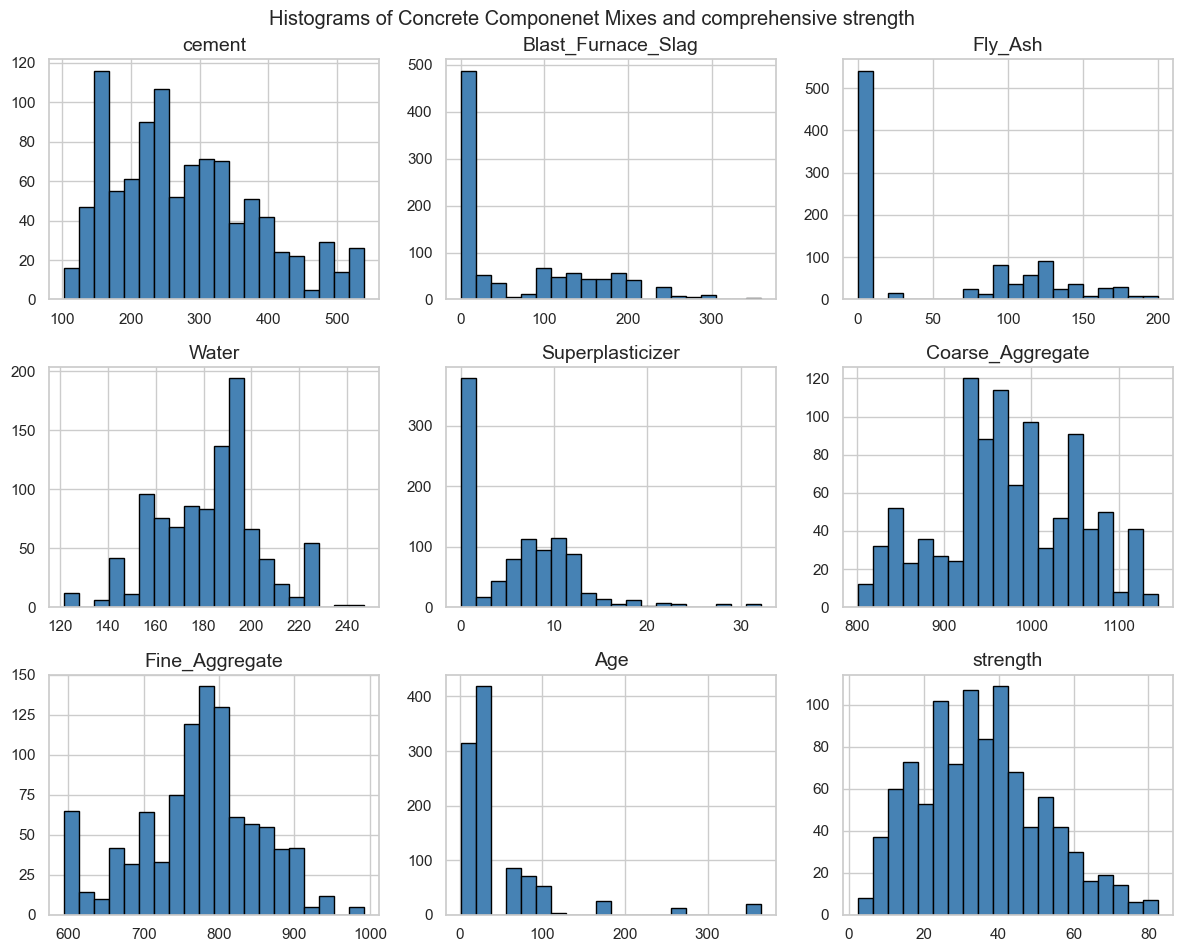

In [15]:
# Plot distribution histogram
data.hist(figsize=(12, 10),  bins=20, color="steelblue", edgecolor="black")
plt.suptitle("Histograms of Concrete Componenet Mixes and comprehensive strength\n", y=0.95)
plt.tight_layout()
plt.savefig(results_dir + "histogram_distribution.png", dpi=300)
plt.show()

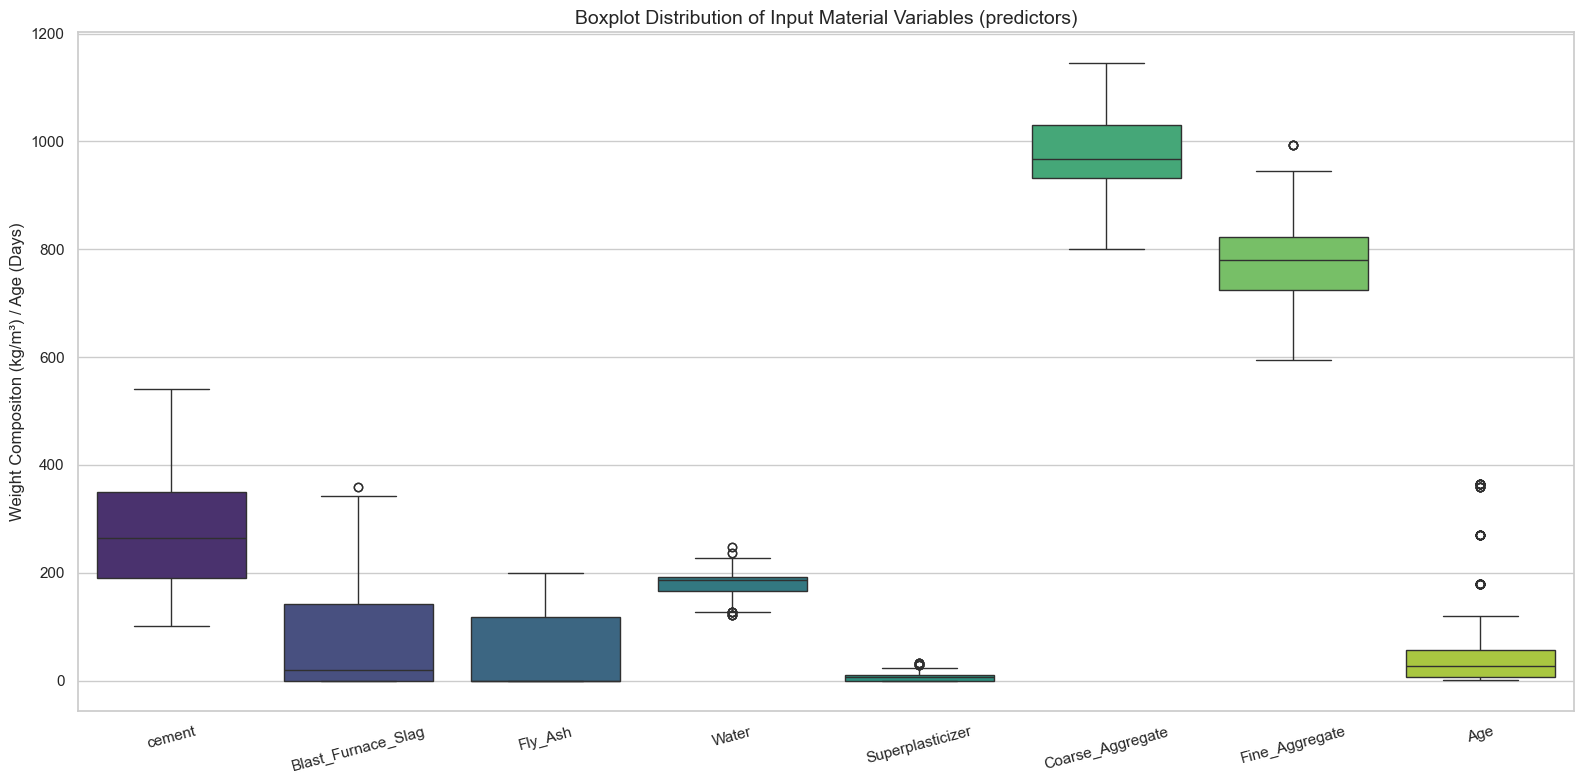

In [16]:
# Plot comparative horizontal boxplots to spot outliers
plt.figure(figsize=(16, 8))
sns.boxplot(data=data.drop(columns=["strength"]), palette="viridis")
plt.title("Boxplot Distribution of Input Material Variables (predictors)")
plt.xticks(rotation=15)
plt.ylabel("Weight Compositon (kg/m³) / Age (Days)")
plt.tight_layout()
plt.savefig(results_dir + "horizontal_boxplot.png", dpi=300)
plt.show()

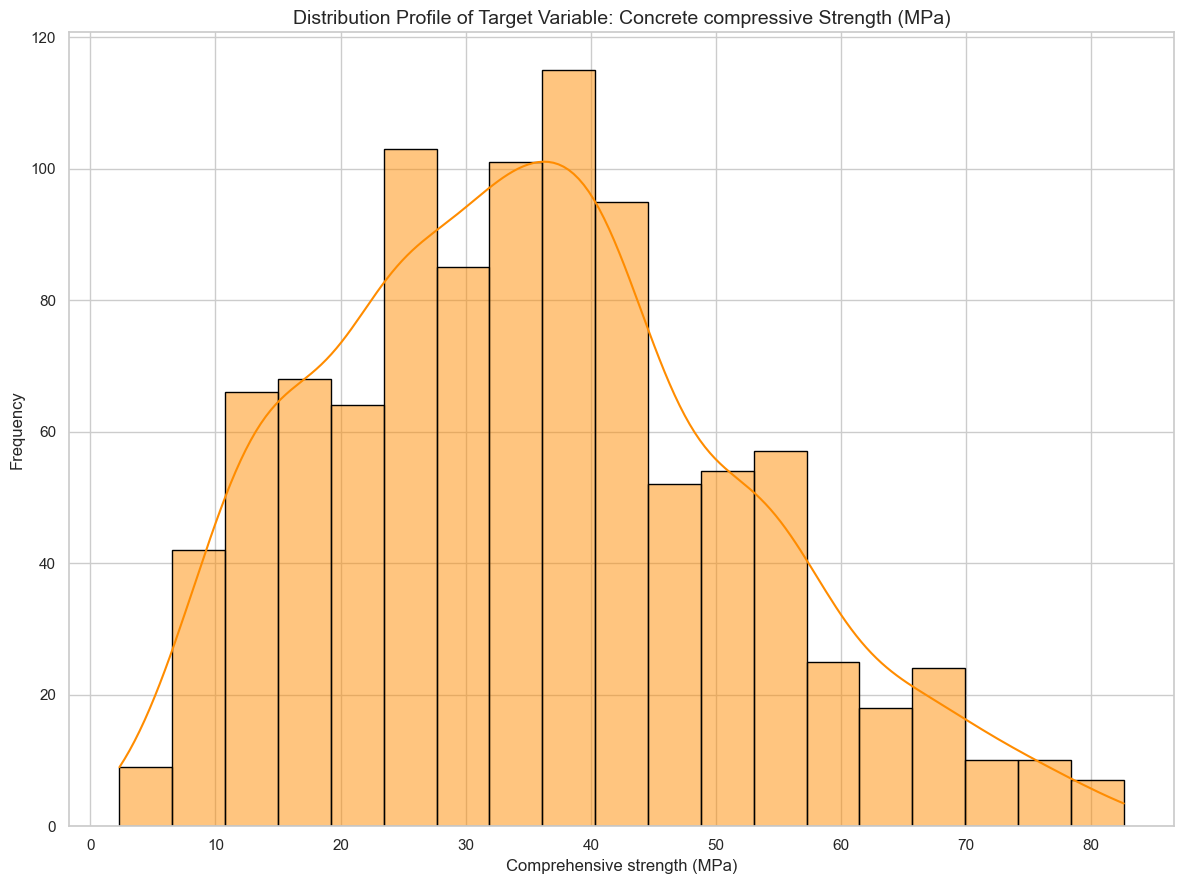

In [17]:
# Analyze the probability density and frequency
plt.figure(figsize=(12, 9))
sns.histplot(data["strength"], kde=True, color="darkorange", edgecolor="black")
plt.title("Distribution Profile of Target Variable: Concrete compressive Strength (MPa)")
plt.xlabel("Comprehensive strength (MPa)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(results_dir + "probability_density.png", dpi=300)
plt.show()

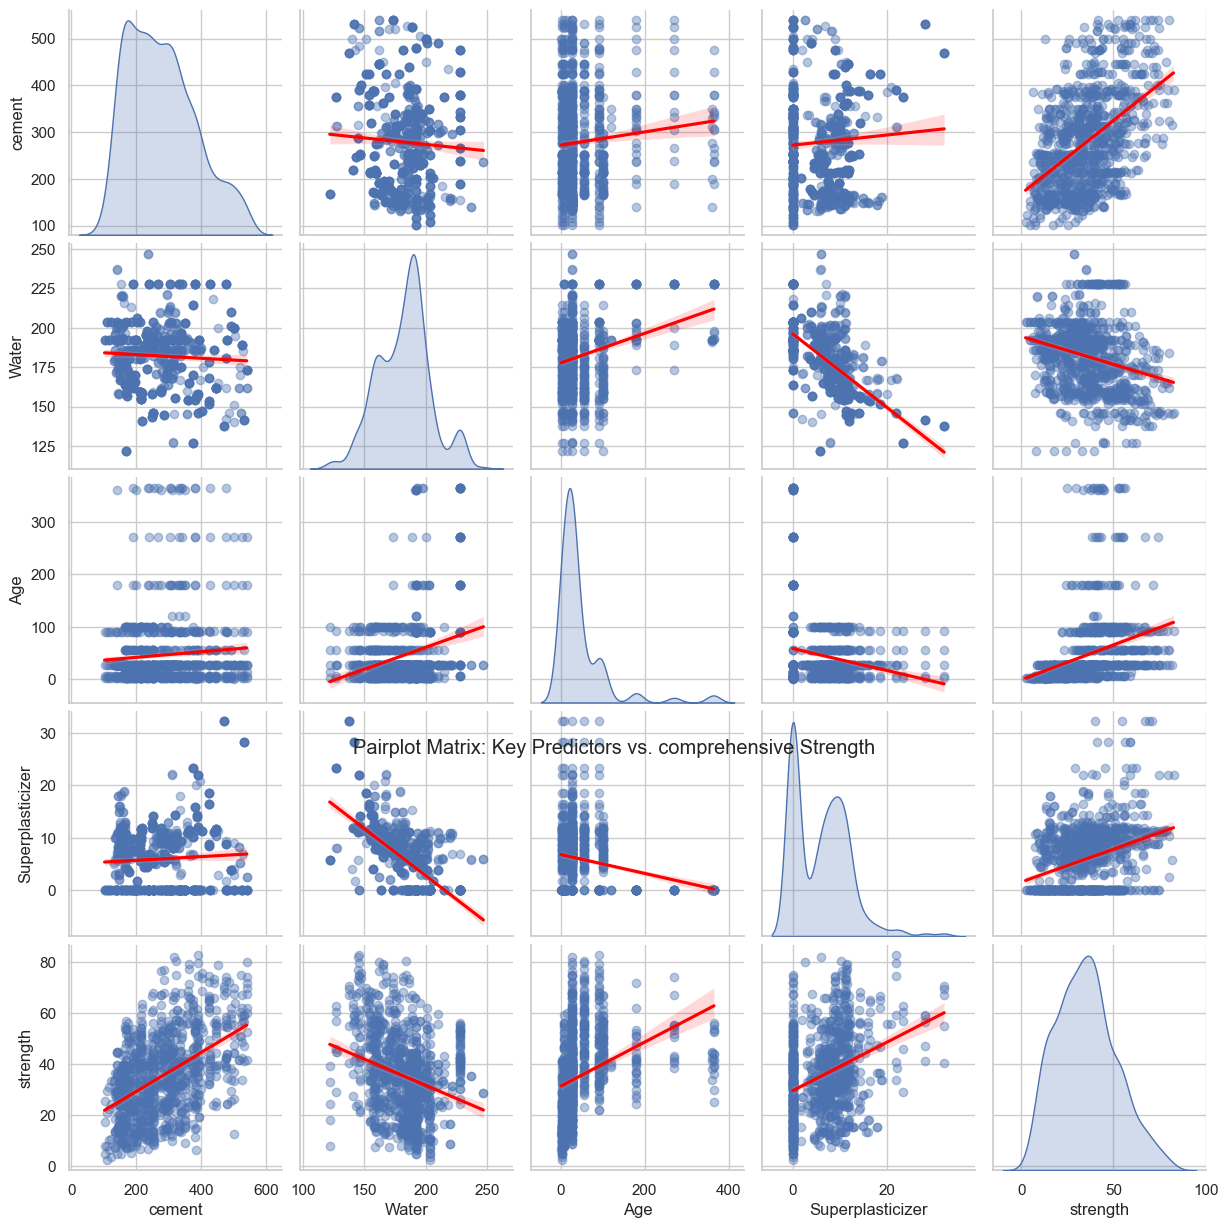

In [18]:
# Render a pairplot regression matrix for the key variable
select_pairplot_col = ["cement", "Water", "Age", "Superplasticizer", "strength"]
sns.pairplot(data[select_pairplot_col], kind="reg", diag_kind="kde",
            plot_kws={"line_kws": {"color": "red"}, "scatter_kws": {"alpha": 0.4}})
plt.suptitle("Pairplot Matrix: Key Predictors vs. comprehensive Strength", y=0.4)
plt.savefig(results_dir + "pairplot_matrix.png", dpi= 300)
plt.show()


Pearson Correlation Coefficients Relative to strength
strength              1.000000
cement                0.488283
Superplasticizer      0.344225
Age                   0.337371
Blast_Furnace_Slag    0.103370
Fly_Ash              -0.080648
Coarse_Aggregate     -0.144710
Fine_Aggregate       -0.186457
Water                -0.269606
Name: strength, dtype: float64 3


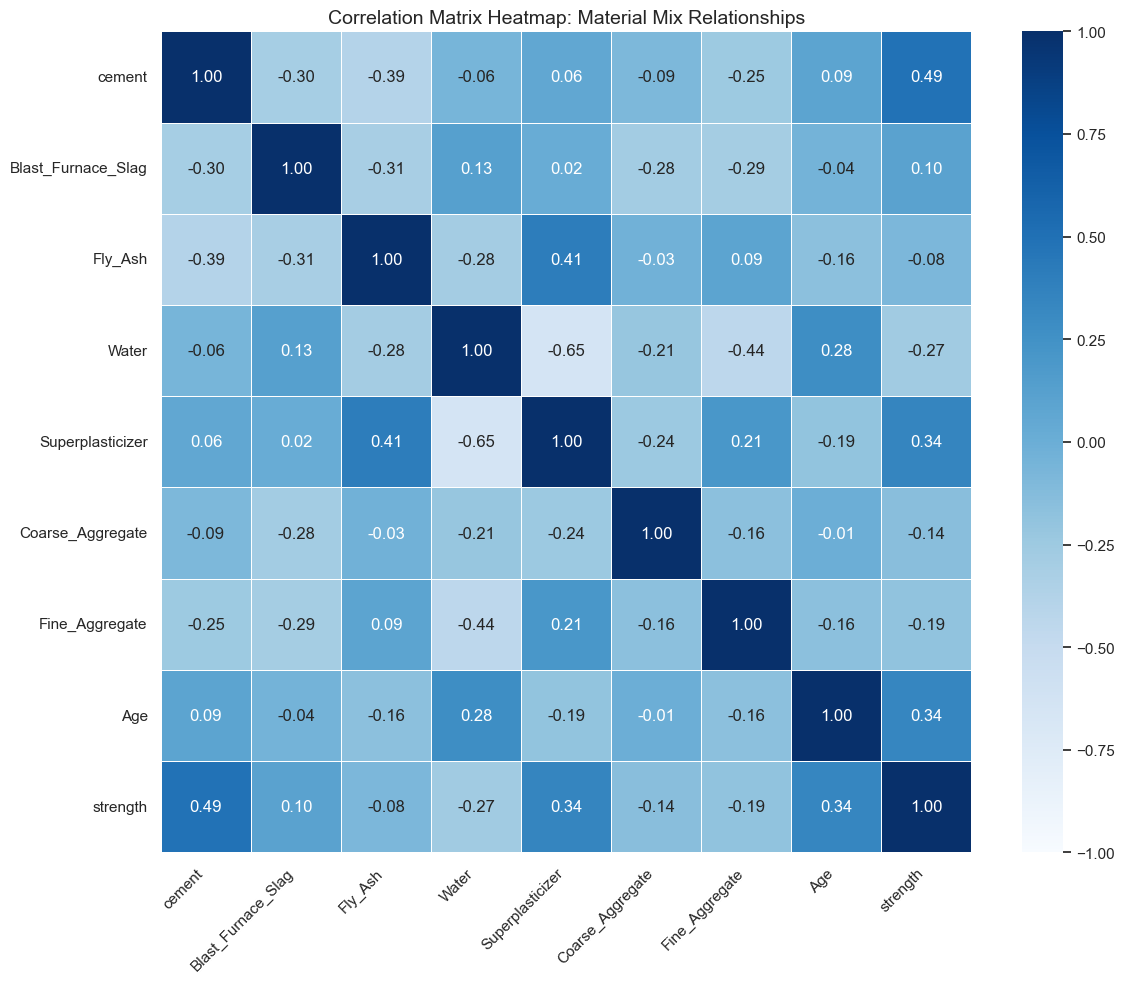

In [19]:
# Compute the pearson product-moment correlation matrix
corr_matrix = data.corr()
print("\nPearson Correlation Coefficients Relative to strength")
print(corr_matrix['strength'].sort_values(ascending=False), round(3))
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap: Material Mix Relationships")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(results_dir + "correlation_matrix.png", dpi=300)
plt.show()

In [20]:
# Select features and determine the target variable
X_sample = data[["cement"]]
y = data["strength"]
x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(X_sample, y, test_size=0.2, random_state=42)


In [21]:
# Fit the Model and programmatically extract its learned weight parameter.
sim_model = LinearRegression()
sim_model.fit(x_train_s, y_train_s)
slope_s = sim_model.coef_[0]
intercept_s = sim_model.intercept_
simple_equation_text = f"strength = ({slope_s:.4f} * Cement ) {intercept_s:.4f}"

print(f"Learned weight/slope (w1): {slope_s:.4f}")
print(f"Learned Intercept Bias (b): {intercept_s:.4f}")
print(f"Programmatic Structural Equation: {simple_equation_text}")


Learned weight/slope (w1): 0.0766
Learned Intercept Bias (b): 13.7606
Programmatic Structural Equation: strength = (0.0766 * Cement ) 13.7606


In [22]:
# Compute key performance matrices
y_pred_s = sim_model.predict(x_test_s)
mean_absolute_error_s = mean_absolute_error(y_test_s, y_pred_s)
mean_squared_error_s = mean_squared_error(y_test_s, y_pred_s)
root_mean_sqr = np.sqrt(mean_squared_error_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(
    f"Performance:\n"
    f"Mean Absolute Error: {mean_absolute_error_s:.2f} MPa²\n"
    f"Root Mean Square Error: {mean_squared_error_s:.2f} Mpa\n"
    f"R²_Score: {r2_s:.4f}"
)

Performance:
Mean Absolute Error: 12.40 MPa²
Root Mean Square Error: 236.48 Mpa
R²_Score: 0.2073


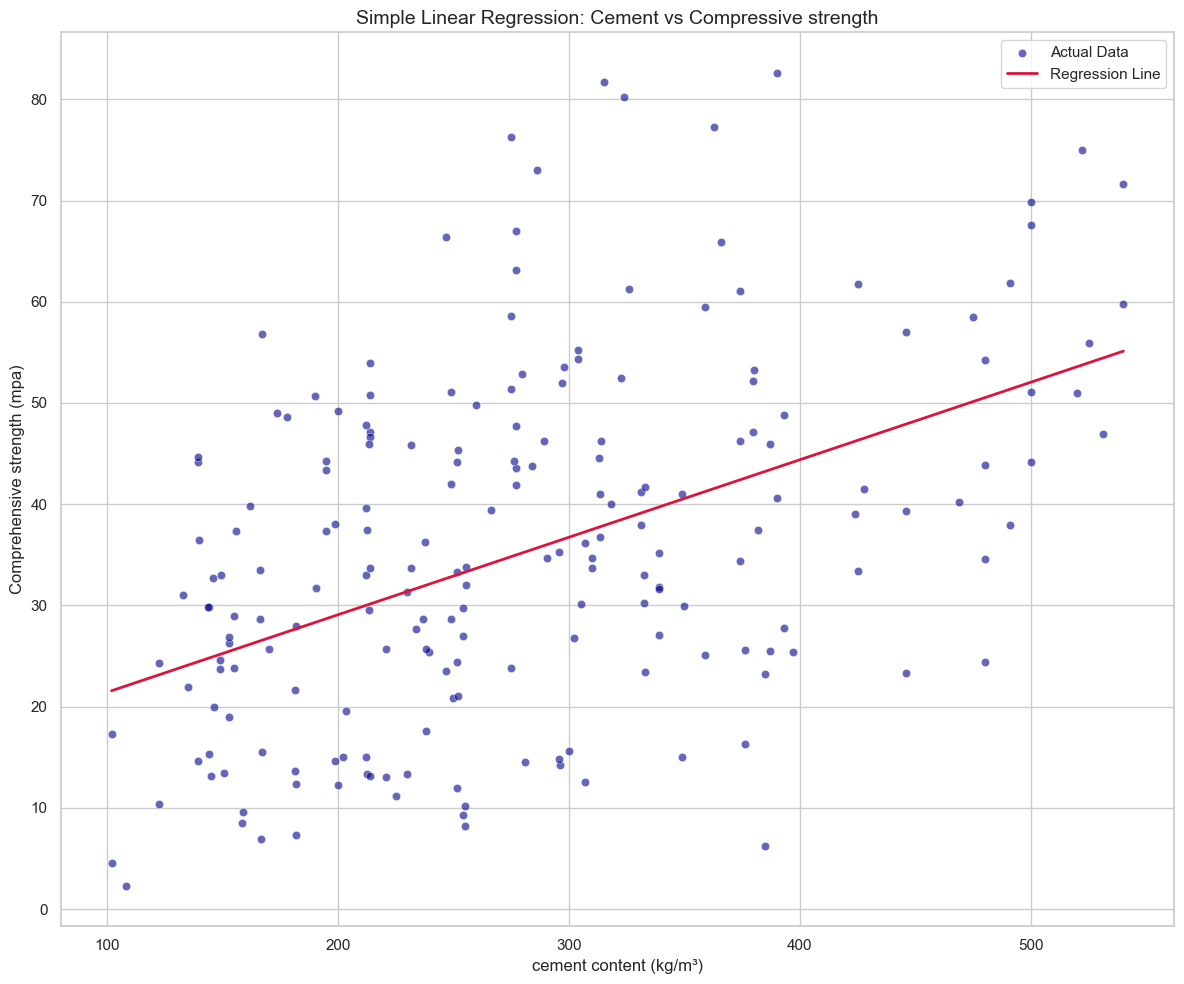

In [23]:
# visualize the trained SLR model trajectory
plt.figure(figsize=(12, 10))
sns.scatterplot(x=x_test_s["cement"], y=y_test_s, color="darkblue", alpha=0.6, label="Actual Data")
# plot predicted regression line (sorted for a clean line)
sort_idx = np.argsort(x_test_s['cement'].values)
plt.plot(x_test_s['cement'].values[sort_idx], y_pred_s[sort_idx], color="crimson", linewidth=2, label="Regression Line")
plt.title("Simple Linear Regression: Cement vs Compressive strength")
plt.xlabel("cement content (kg/m³)")       
plt.ylabel("Comprehensive strength (mpa)")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir + "simple_linear_regression.png", dpi=300)
plt.show()

In [24]:
# Isolate all 8 chemical predictions
x_multi = data.drop(columns=["strength"])
x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(x_multi, y, test_size=0.2, random_state=42)

In [25]:
# Train the MLR model and assemble models
multi_model = LinearRegression()
multi_model.fit(x_train_m, y_train_m)

coeff_df = pd.DataFrame({
    "Component Feature": x_multi.columns, 
    "Learned Weight (Beta Coefficient)": multi_model.coef_
})

intercept_m = multi_model.intercept_
print("\nMultiple Linear Regression Learned Weights")
print(coeff_df.to_string(index=False))
print(f"Learned Intercept Bias (b): {intercept_m:.4f}")


Multiple Linear Regression Learned Weights
 Component Feature  Learned Weight (Beta Coefficient)
            cement                           0.116647
Blast_Furnace_Slag                           0.098046
           Fly_Ash                           0.084590
             Water                          -0.131733
  Superplasticizer                           0.330068
  Coarse_Aggregate                           0.015468
    Fine_Aggregate                           0.020615
               Age                           0.110646
Learned Intercept Bias (b): -23.2328


In [26]:
# Generate the full multi-variable algebraic iteration
equation_terms = []
for _, row in coeff_df.iterrows():
    feat = row["Component Feature"]
    weight = row["Learned Weight (Beta Coefficient)"]
    equation_terms.append(f"({weight:.4f} * {feat})")

multi_equation_text = f"Strength = {intercept_m:.4f} + " + " + ".join(equation_terms)
print(f"\nProgrammatic structural Equation:\n{multi_equation_text}")



Programmatic structural Equation:
Strength = -23.2328 + (0.1166 * cement) + (0.0980 * Blast_Furnace_Slag) + (0.0846 * Fly_Ash) + (-0.1317 * Water) + (0.3301 * Superplasticizer) + (0.0155 * Coarse_Aggregate) + (0.0206 * Fine_Aggregate) + (0.1106 * Age)


C:\Users\Scientist\AppData\Local\Temp\ipykernel_15584\2917346529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeff_df, x='Learned Weight (Beta Coefficient)', y='Component Feature', palette="coolwarm")


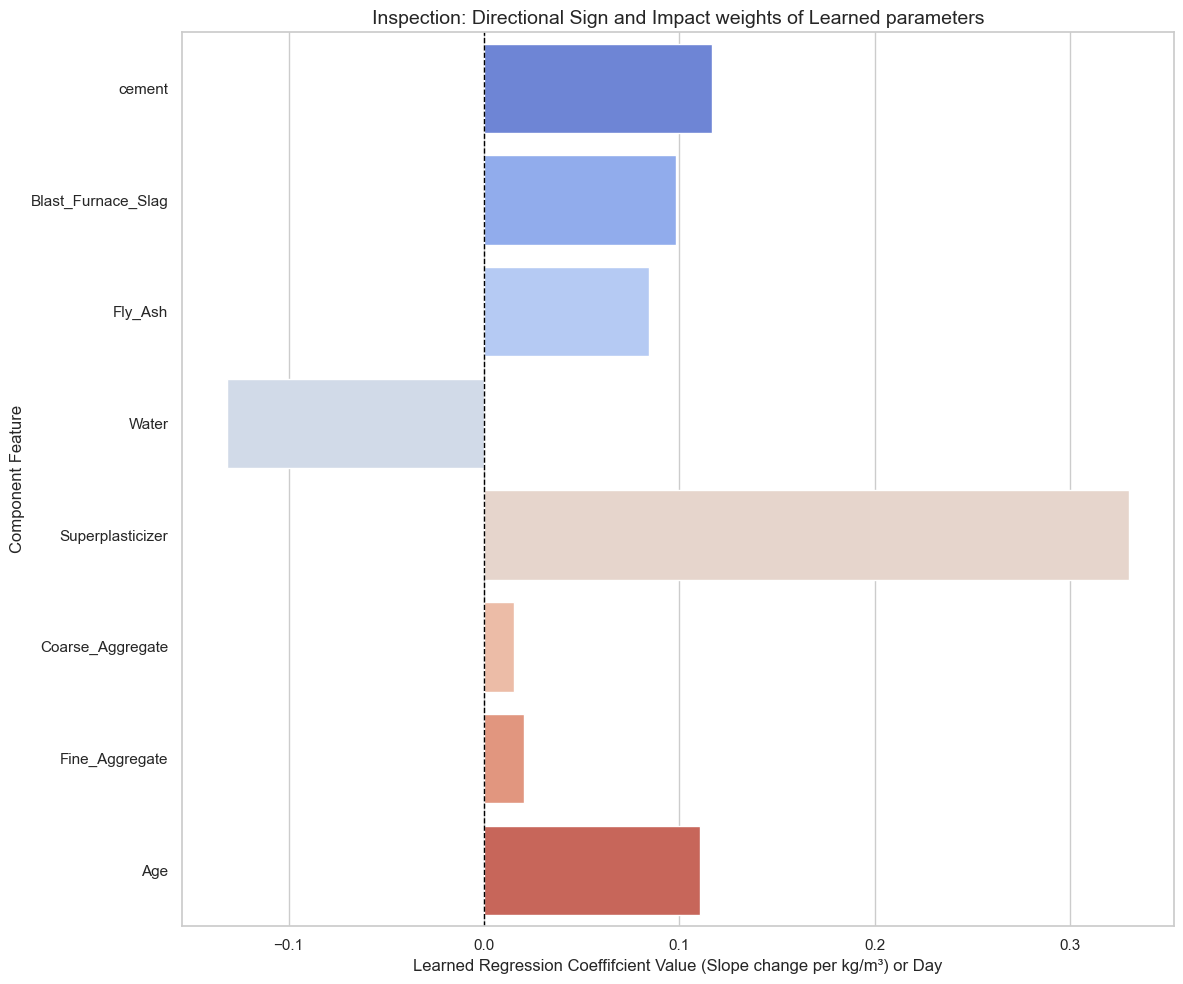

In [27]:
# Graph the horizontal bar chart to display key parameters
plt.figure(figsize=(12, 10))
sns.barplot(data=coeff_df, x='Learned Weight (Beta Coefficient)', y='Component Feature', palette="coolwarm")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.title("Inspection: Directional Sign and Impact weights of Learned parameters")
plt.xlabel("Learned Regression Coeffifcient Value (Slope change per kg/m³) or Day")
plt.tight_layout()
plt.savefig(results_dir + "feature_distribution_dir_magnitude.png", dpi=300)

plt.show()

In [28]:
# Generate the MLR predictions
y_pred_m = multi_model.predict(x_test_m)
mean_absolute_error_m = mean_absolute_error(y_test_m, y_pred_m)
mean_squared_error_m = mean_squared_error(y_test_m, y_pred_m)
root_mean_sqr_m = np.sqrt(mean_squared_error_m)
r2_m = r2_score(y_test_m, y_pred_m)


In [29]:
# Calculate the training set metrics 
r2_train_s = r2_score(y_train_s, sim_model.predict(x_train_s))
r2_train_m = r2_score(y_train_m, multi_model.predict(x_train_m))
# Ensure training R² uses training predictions (not test)
r2_train_m = r2_score(y_train_m, multi_model.predict(x_train_m))

print("\nGeneralization & Performance Comparison")
print(f"Simple model -> Trained R_squared: {r2_train_s:.4f} | Test R_squared: {r2_s:.4f}")
print(f"Multiple Model -> Train R_squared: {r2_train_m:.4f} | Test R_squared: {r2_m:.4f}")



Generalization & Performance Comparison
Simple model -> Trained R_squared: 0.2469 | Test R_squared: 0.2073
Multiple Model -> Train R_squared: 0.6098 | Test R_squared: 0.5801


In [30]:
# Structure and print the final metrics
comparison_metrics = pd.DataFrame({
    "Metric": ["MAE (mpa)", "MSE (mpa_squared)", "RMSE (mpa)", "R_squared score"], 
    "simple LR (cement)": [mean_absolute_error_s, mean_squared_error_s, root_mean_sqr, r2_s],
    "Multiple LR (All)": [mean_absolute_error_m, mean_squared_error_m, root_mean_sqr_m, r2_m]

})
print("\nFinal Test partition comparison Table:")
print(comparison_metrics.round(4).to_string(index=False))


Final Test partition comparison Table:
           Metric  simple LR (cement)  Multiple LR (All)
        MAE (mpa)             12.3955             8.8960
MSE (mpa_squared)            236.4841           125.2653
       RMSE (mpa)             15.3780            11.1922
  R_squared score              0.2073             0.5801


In [31]:
# Calculate  multivariate residual error arrays.
residuals_m = y_test_m - y_pred_m
residuals_m

951    -4.447259
654     7.585905
706     3.864548
538    -2.833426
389     1.255585
         ...    
232    20.189293
802     4.668773
358    20.045832
234   -11.475882
374    -7.648523
Name: strength, Length: 201, dtype: float64

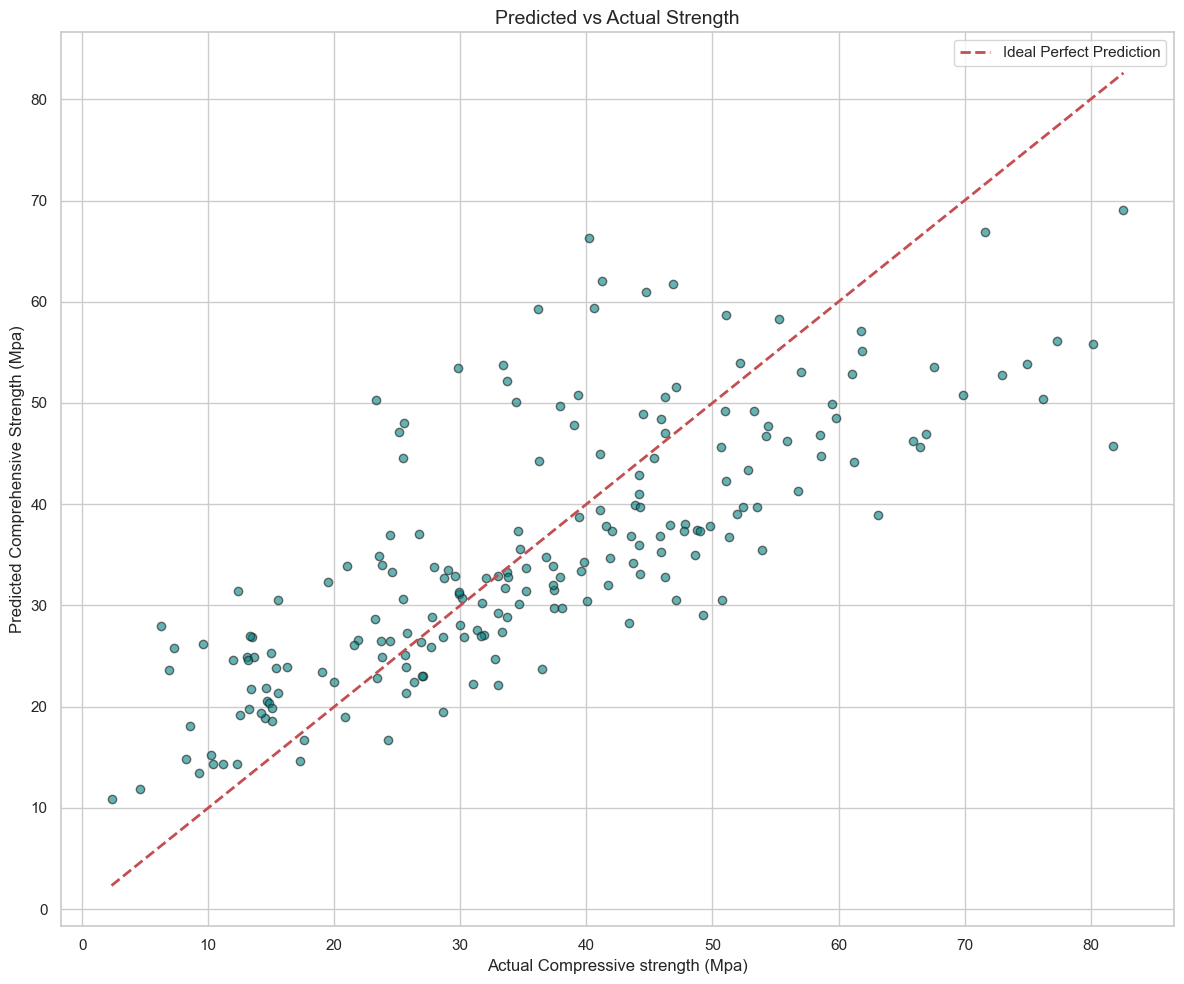

In [32]:
# Predicted vs Actual strength
plt.figure(figsize=(12, 10))
plt.scatter(y_test_m, y_pred_m, color="teal", alpha=0.6, edgecolor="k")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="Ideal Perfect Prediction")
plt.title("Predicted vs Actual Strength")
plt.xlabel("Actual Compressive strength (Mpa)")
plt.ylabel("Predicted Comprehensive Strength (Mpa)")
plt.legend()
plt.tight_layout()
plt.savefig(results_dir + "predicted_vs_actual.png", dpi=300)
plt.show()

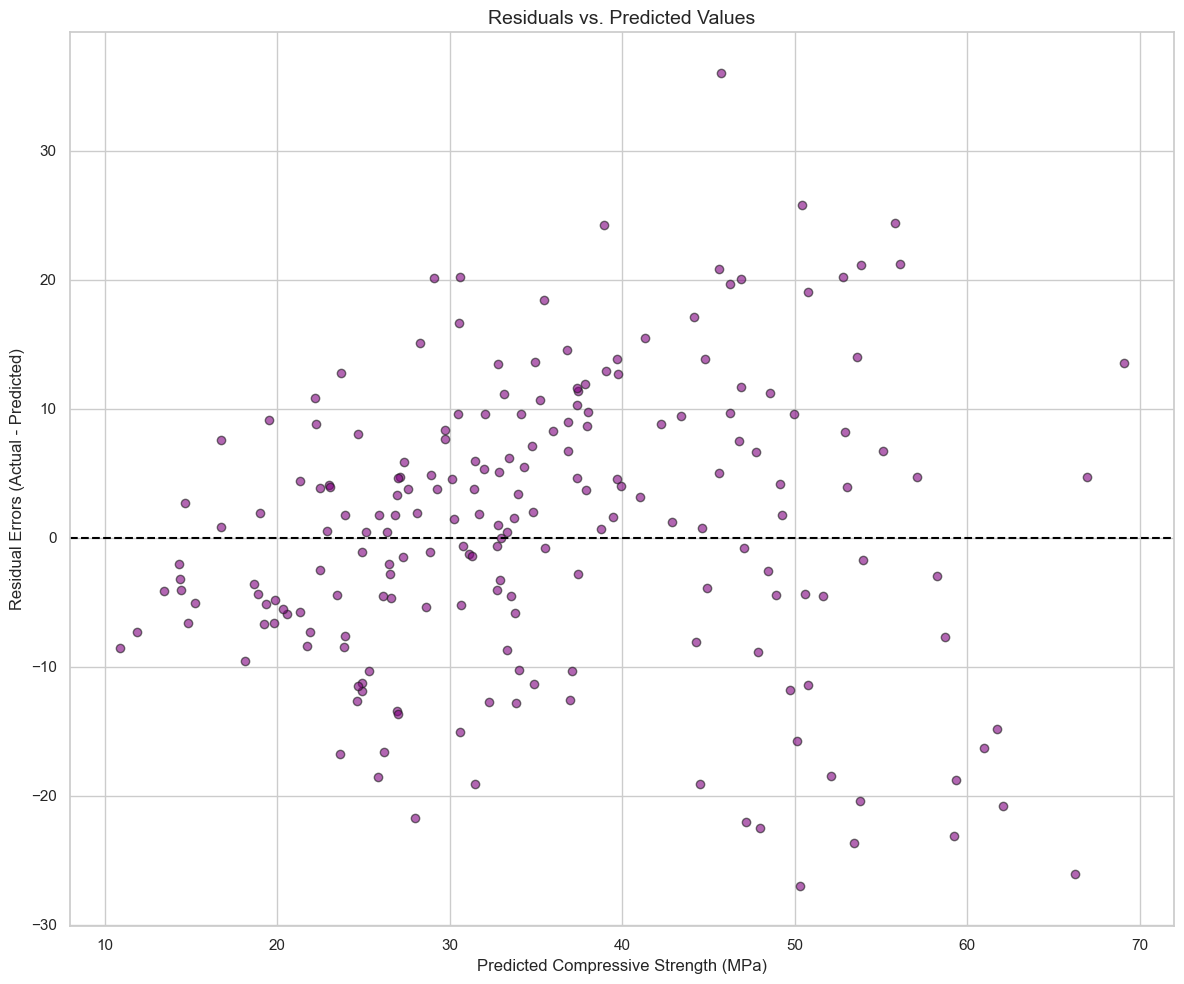

In [33]:
# Residuals vs predicted
plt.figure(figsize=(12, 10))
plt.scatter(y_pred_m, residuals_m, color='purple', alpha=0.6, edgecolor='k')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.title("Residuals vs. Predicted Values")
plt.xlabel("Predicted Compressive Strength (MPa)")
plt.ylabel("Residual Errors (Actual - Predicted)")
plt.tight_layout()
plt.savefig(results_dir + "residual_errors.png", dpi=300)
plt.show()

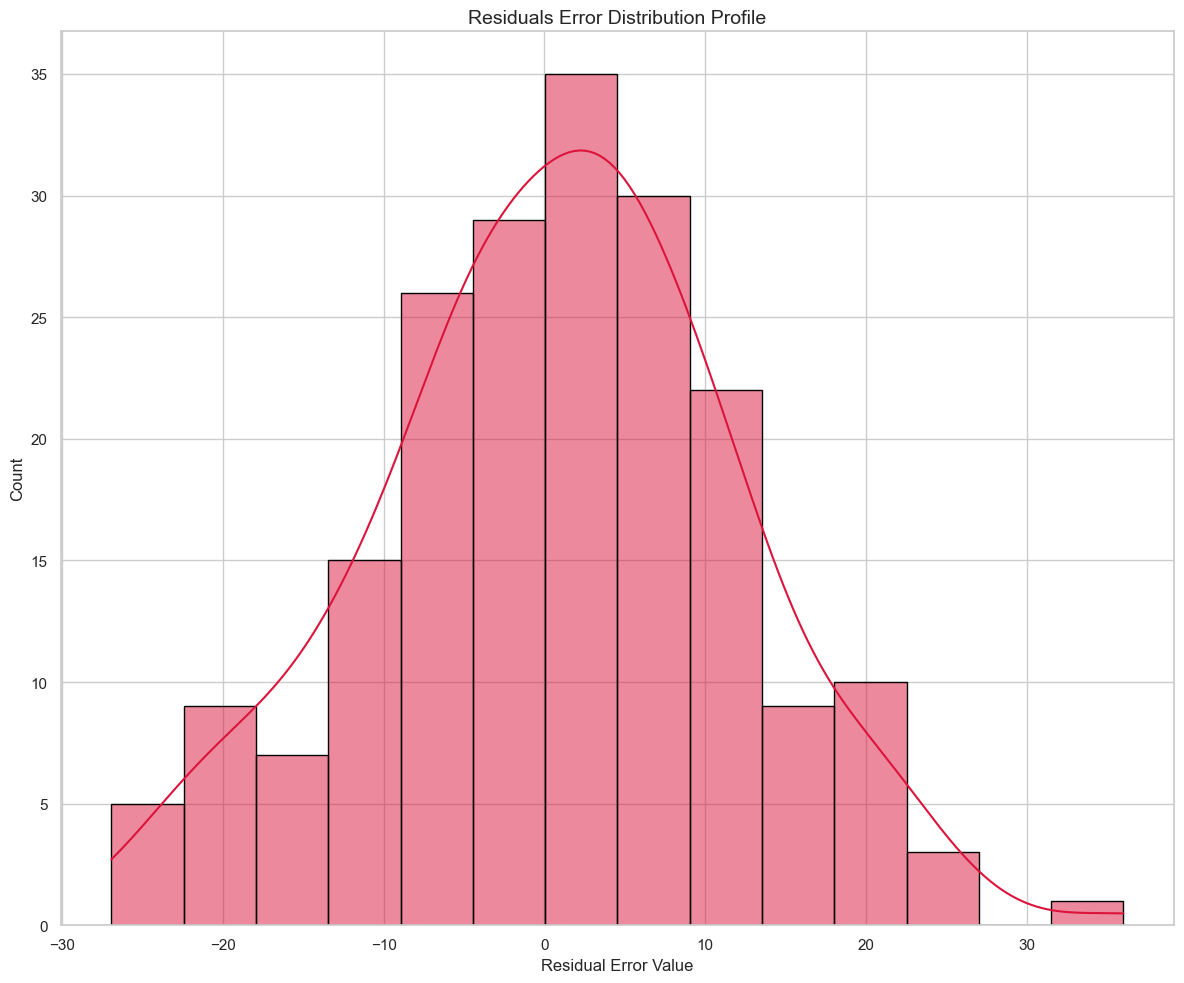

In [34]:
# Error Distribution Profile Histogram
plt.figure(figsize=(12, 10))
sns.histplot(residuals_m, kde=True, color="crimson", edgecolor="black")
plt.title("Residuals Error Distribution Profile")
plt.xlabel("Residual Error Value")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(results_dir + "residual_error_distribution.png", dpi=300)
plt.show()